# LSTM Model
This notebook trains an LSTM neural network to predict the winner of the SC2 match at each 10 second event window in the games event stream.

## Setup

In [126]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss, roc_auc_score

from keras.regularizers import l2
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam

from starcraft_predictor.replays.player_stats_tracker import PLAYER_STATS_FIELDS
from starcraft_predictor.lstm import Sc2LSTM
from starcraft_predictor.processing.data_splitter import train_test_split

## Load Data

In [127]:
data = pd.read_pickle("../../data/Terran_vs_Zerg.pkl")
# convert target to 0, 1
data["winner"] = data["winner"] - 1

NON_FEATURES = [
    "filehash",
    "winner",
    "player_1_race",
    "player_2_race",
]

FEATURES = [col for col in data.columns if col not in NON_FEATURES]

TARGET = "winner"

In [128]:
FEATURES = FEATURES[1:33]

In [129]:
print(f"Number of unique games: {data['filehash'].nunique()}")
print(f"Number of features: {len(FEATURES)}")

Number of unique games: 302
Number of features: 32


In [130]:
for feature in FEATURES:
    data[feature] = data[feature].astype(float)

In [131]:
for feature in PLAYER_STATS_FIELDS:
    data[f"diff_{feature}"] = data[f"player_1_{feature}"] - data[f"player_2_{feature}"]

/var/folders/tw/z8zztw612_954yxzktfwb6480000gp/T/ipykernel_81467/3197868903.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f"diff_{feature}"] = data[f"player_1_{feature}"] - data[f"player_2_{feature}"]
/var/folders/tw/z8zztw612_954yxzktfwb6480000gp/T/ipykernel_81467/3197868903.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f"diff_{feature}"] = data[f"player_1_{feature}"] - data[f"player_2_{feature}"]
/var/folders/tw/z8zztw612_954yxzktfwb6480000gp/T/ipykernel_81467/3197868903.py:2: PerformanceWarning: DataFram

In [151]:
NEW_FEATURES = [f"diff_{feature}" for feature in PLAYER_STATS_FIELDS]

In [152]:
CHOSEN_FEATURES = FEATURES + NEW_FEATURES

## Prepare Data

In [153]:
# split the data intro training and testing samples
train_data, test_data = train_test_split(data, "filehash", 0.2)

In [154]:
# Scale the features
scaler = StandardScaler()
scaler.fit(train_data[CHOSEN_FEATURES])
train_data.loc[:, CHOSEN_FEATURES] = scaler.transform(train_data[CHOSEN_FEATURES])
test_data.loc[:, CHOSEN_FEATURES] = scaler.transform(test_data[CHOSEN_FEATURES])

## Train Model

In [175]:
lstm_params = {
    "units": 10,
    # "dropout": 0.1,
    # "kernel_regularizer": l2(0.01),
    # "recurrent_regularizer": l2(0.01),
    # "bias_regularizer": l2(0.01),
}

In [176]:
model = Sc2LSTM(
    features=CHOSEN_FEATURES,
    target=TARGET,
    unique_id="filehash",
    timestamp="seconds",
    lstm_params=lstm_params,
)

In [192]:
model.model.count_params()

2371

In [189]:
dir(model.model)

['__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_trackable_child',
 '_add_variable_with_custom_getter',
 '_aggregate_additional_loss',
 '_allow_non_tensor_positional_args',
 '_api_export_path',
 '_api_export_symbol_id',
 '_assert_compile_called',
 '_assert_input_compatibility',
 '_assign_variable_values',
 '_auto_config',
 '_build_at_init',
 '_build_by_run_for_kwargs',
 '_build_by_run_for_single_pos_arg',
 '_build_shapes_dict',
 '_call_context_args',
 '_call_has_context_arg',
 '_call_has_mask_arg',
 '_call_has_training_arg',
 '_call_signature',
 '_called',
 '_check_quantize_args',
 '_check_super_called',
 '_checkpoint_adapter',
 '_

In [177]:
model.train(
    train_data=train_data,
    validation_data=test_data,
    epochs=1000,
    batch_size=10,
    verbose=0,
)


Epoch 23: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 13.


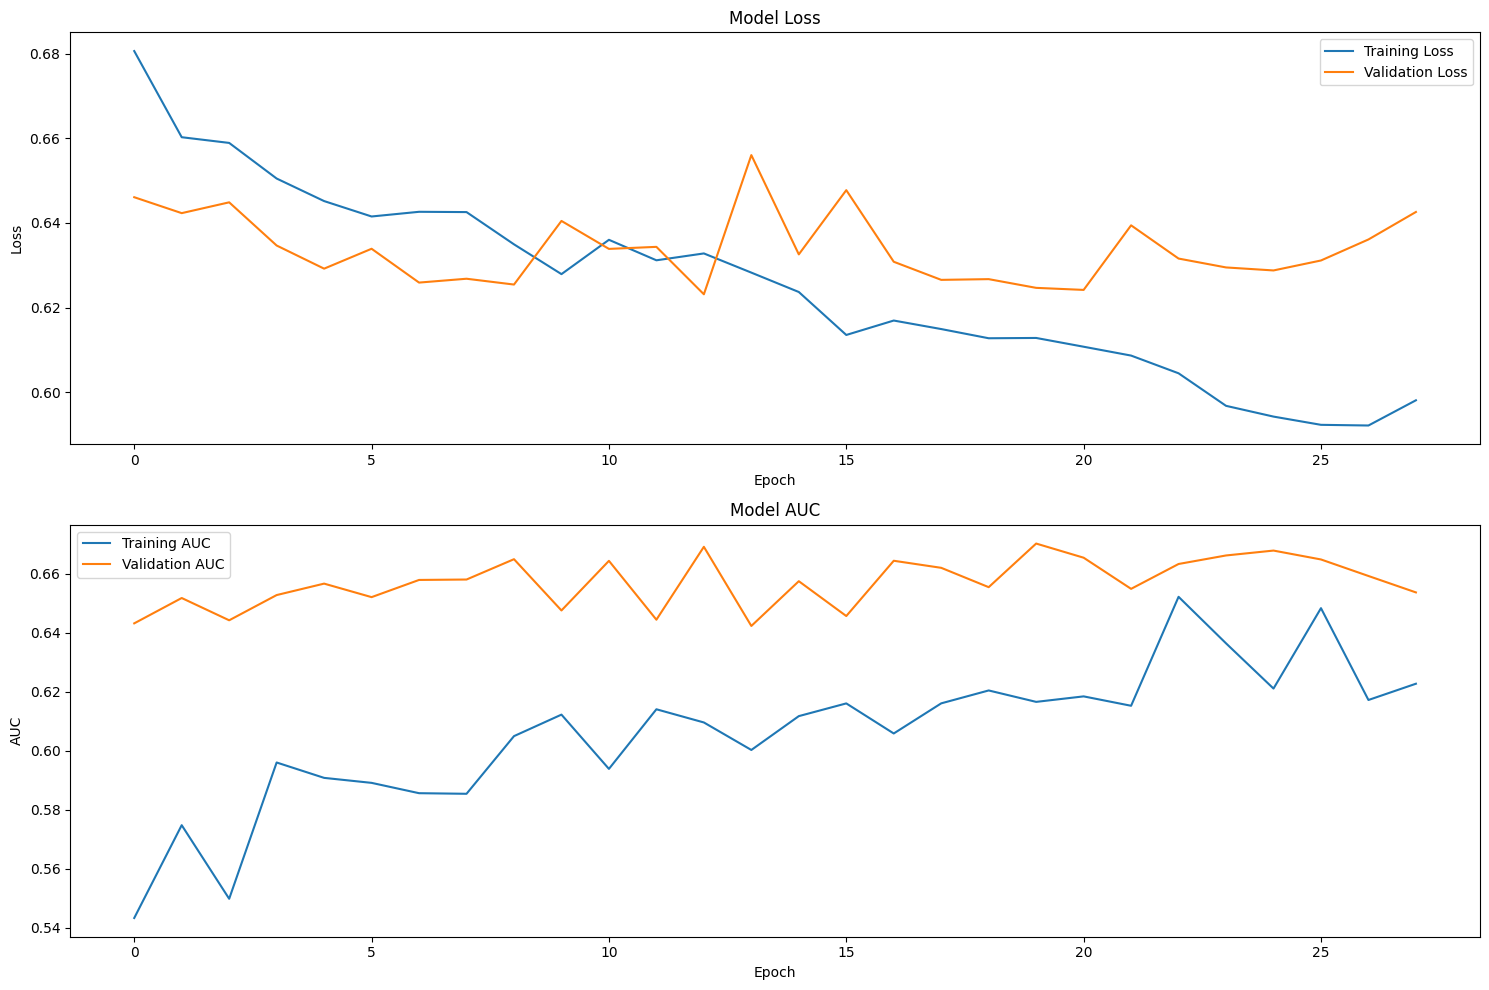

In [178]:
model.plot_training_history()

## Evaluate Model

In [179]:
model.evaluate(train_data)

{'test_loss': 0.5106184482574463, 'test_AUC': 0.8032321333885193}

In [180]:
model.evaluate(test_data)

{'test_loss': 0.5586929321289062, 'test_AUC': 0.7810371518135071}

In [181]:
model.evaluate(train_data)

{'test_loss': 0.5106184482574463, 'test_AUC': 0.8032321333885193}

In [182]:
model.evaluate(test_data)

{'test_loss': 0.5586929321289062, 'test_AUC': 0.7810371518135071}

In [183]:
def evaluate_specific_match(data, filehash: str):
    game_data = data[data["filehash"] == filehash].copy()
    
    predictions = model.predict(game_data)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.lineplot(x=predictions["seconds"], y=predictions["predictions"], color="blue")
    sns.lineplot(x=predictions["seconds"], y=game_data["winner"], color="red")
    sns.lineplot(x=predictions["seconds"], y=0.5, color="grey", alpha=0.5)
    plt.ylim(-0.01, 1.01)
    plt.xlim(predictions["seconds"].min(), predictions["seconds"].max())
    plt.xlabel("seconds")
    plt.ylabel("prediction")
    plt.show()

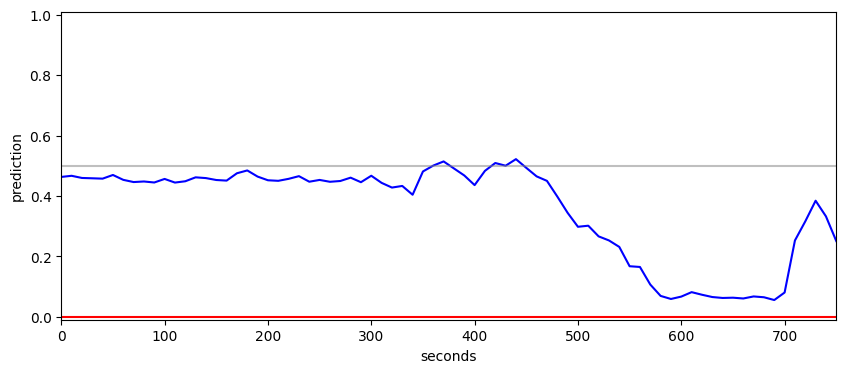

In [184]:
filehash = test_data["filehash"].unique()[14]
_ = evaluate_specific_match(test_data, filehash)

In [185]:
scored_train_batch = model.predict(train_data)
scored_test_batch = model.predict(test_data)

In [186]:
def evaluate_for_specific_minute(data, minute):
    subset = data[(data["seconds"] <= minute*60) & (data["seconds"] > (minute-1)*60)]
    count = subset.shape[0]
    brier_score = brier_score_loss(subset["winner"], subset["predictions"])
    roc_auc = roc_auc_score(subset["winner"], subset["predictions"])
    return brier_score, roc_auc, count

/Users/ned.webster/Documents/python_projects/personal_projects/starcraft_predictor/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Text(0.5, 1.0, 'Brier Score: 0.19, ROC AUC: 0.783')

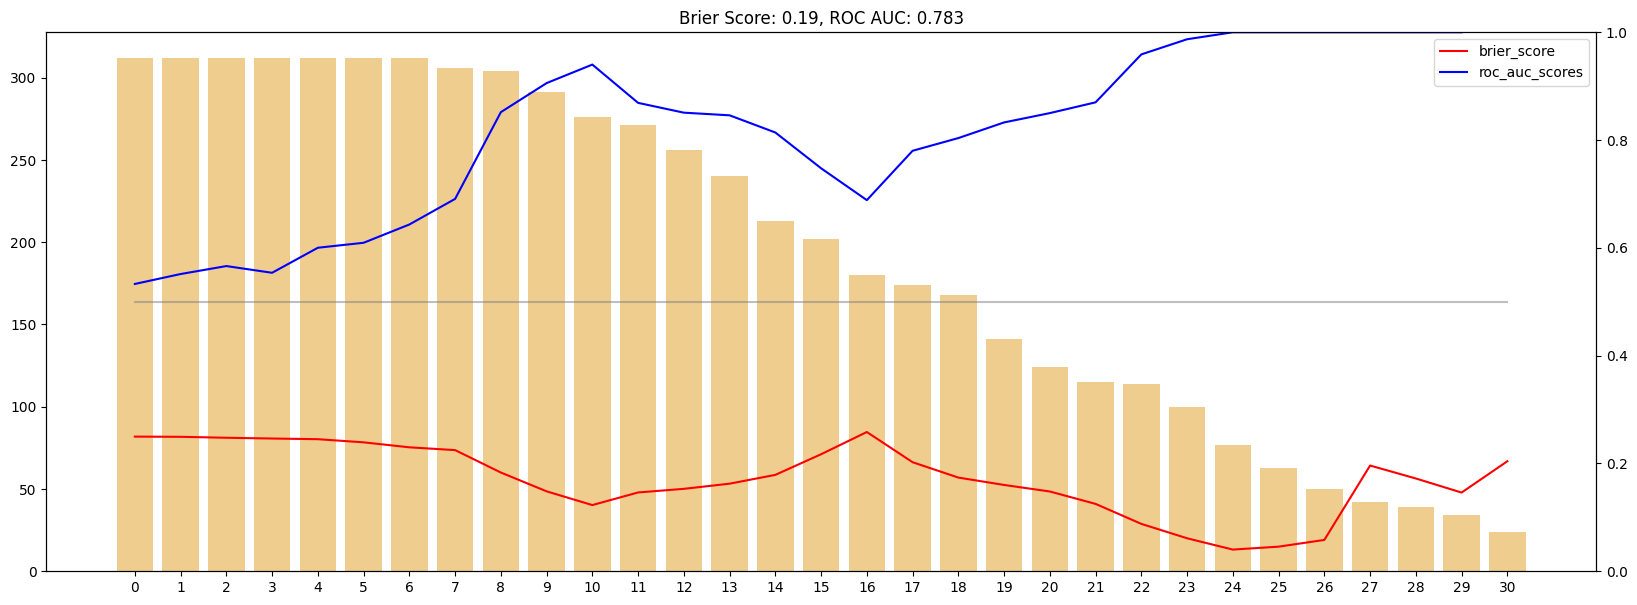

In [187]:
scored_test_batch["winner"] = test_data["winner"]
scored_test_batch["seconds"] = test_data["seconds"]

brier_scores = []
roc_aucs = []
counts = []

overall_brier_score = brier_score_loss(scored_test_batch["winner"], scored_test_batch["predictions"])
overall_roc_auc = roc_auc_score(scored_test_batch["winner"], scored_test_batch["predictions"])
overall_brier_score, overall_roc_auc

for i in range(1, 32):
    brier_score, roc_auc, count = evaluate_for_specific_minute(scored_test_batch, i)
    brier_scores.append(brier_score)
    roc_aucs.append(roc_auc)
    counts.append(count)

fig, ax = plt.subplots(figsize=(20, 7))
sns.barplot(x=np.arange(0, 31), y=counts, color="orange", alpha=0.5)
ax2 = ax.twinx()

sns.lineplot(x=np.arange(0, 31), y=brier_scores, label="brier_score", color="red")
sns.lineplot(x=np.arange(0, 31), y=roc_aucs, label="roc_auc_scores", color="blue")
sns.lineplot(x=np.arange(0, 31), y=0.5, color="grey", alpha=0.5)
ax2.set_ylim(0, 1)
plt.title(f"Brier Score: {np.round(overall_brier_score, 3)}, ROC AUC: {np.round(overall_roc_auc, 3)}")